# CareerBot v0.4 — Full Prototype + Gradio + Google Drive Persistence
### Intent Classification + Static Responses + Chat UI + Save/Load Centroids

**What's new in this version:** the computed centroids (the "trained" artifact of this pipeline) now save to Google Drive automatically, and load back instantly on future runs instead of recomputing from scratch.

**Important note on what's actually being saved:** this pipeline doesn't train a neural network, so there's no `.h5` or `.pt` model file. What gets saved is the **centroids dictionary** (one averaged vector per intent), that's the equivalent artifact here. The embedding model itself (`all-MiniLM-L6-v2`) doesn't need saving, it just re-downloads from HuggingFace each session (fast, a few seconds).


## 1. Setup

In [50]:
!pip install -q sentence-transformers scikit-learn pandas matplotlib seaborn gradio groq

In [51]:
import numpy as np
import pandas as pd
import random
import pickle
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

RANDOM_STATE = 42
MODEL_NAME = "all-MiniLM-L6-v2"

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/CareerBot"
os.makedirs(SAVE_DIR, exist_ok=True)
CENTROIDS_PATH = os.path.join(SAVE_DIR, "centroids.pkl")

print(f"Save location: {CENTROIDS_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save location: /content/drive/MyDrive/CareerBot/centroids.pkl


## 2. Mount Google Drive

This asks for permission once per session (click the link, choose your account, allow access). After this, `/content/drive/MyDrive/` maps to your actual Google Drive.

In [52]:
# CareerBot Dataset Authoring & Combination
# Combines manual seed utterances and LLM-augmented paraphrases across 10 intents.

SEED_DATA = {
    "career_path_exploration": [
        "What career paths can I take as a CS graduate?",
        "I don't know what to specialize in, can you help me figure it out?",
        "What jobs can I get with a computer science degree?",
        "Should I go into software engineering or data science?",
        "What are the different career tracks in tech?",
        "I'm confused about which CS field to pursue",
        "What options do I have after graduating CS?",
        "Can you suggest career paths based on my interests in AI?",
        "What's a good career direction for someone who likes backend development?",
        "I like both design and coding, what career fits that?",
        "What careers are available for someone who enjoys problem solving?",
        "Where can a CS degree take me career-wise?",
        "What's the difference between pursuing web dev vs cybersecurity as a career?",
        "I'm undecided about my specialization, what are my options?",
        "What career paths are in demand right now for CS students?",
    ],
    "skill_recommendation": [
        "What skills do I need to become a data scientist?",
        "What should I learn to get into machine learning?",
        "Which programming languages should I focus on?",
        "What technical skills are employers looking for in web developers?",
        "How do I build my skills for a cybersecurity role?",
        "What tools should I learn for a career in DevOps?",
        "I want to improve my coding skills, where do I start?",
        "What soft skills matter for software engineering jobs?",
        "What should I study to prepare for a UI/UX design role?",
        "Which frameworks should I learn for backend development?",
        "What certifications would help me become a cloud engineer?",
        "How do I know which skills to prioritize as a beginner?",
        "What's the skill roadmap for becoming a mobile app developer?",
        "Do I need to learn statistics for a data analyst role?",
        "What skills are essential for a QA engineer?",
    ],
    "resume_portfolio_guidance": [
        "Can you help me improve my resume?",
        "What should I include in my portfolio as a CS student?",
        "How do I write a good summary for my resume?",
        "What projects should I showcase in my portfolio?",
        "How long should a fresh graduate's resume be?",
        "Can you review my resume format?",
        "What's the best way to present my GitHub projects?",
        "How do I list my skills section effectively?",
        "Should I include a personal website in my job applications?",
        "What mistakes should I avoid in my resume?",
        "How do I make my resume stand out with no work experience?",
        "What should my portfolio site include as an aspiring developer?",
        "How do I describe my thesis project in my resume?",
        "What format should I use for a tech resume?",
        "Can you give tips on writing a compelling cover letter?",
    ],
    "internship_job_search": [
        "Where can I find internships for CS students?",
        "How do I apply for a software engineering internship?",
        "What companies hire CS interns in the Philippines?",
        "When should I start applying for internships?",
        "How do I find entry-level developer jobs?",
        "What platforms should I use to search for tech jobs?",
        "How many internship applications should I send out?",
        "Do you have tips on finding remote internships?",
        "What's the best way to network for job opportunities?",
        "How do I know if a job posting is legit?",
        "Where can I look for on-the-job training programs?",
        "What's the difference between OJT and internship requirements?",
        "How early should I start looking for a job before graduation?",
        "Can you suggest job boards for fresh CS graduates?",
        "How do I reach out to recruiters on LinkedIn?",
    ],
    "interview_preparation": [
        "How do I prepare for a technical interview?",
        "What questions are usually asked in coding interviews?",
        "Can you help me practice for a behavioral interview?",
        "What should I expect in a software engineering interview?",
        "How do I answer 'tell me about yourself' in an interview?",
        "What are common data structures questions asked in interviews?",
        "How do I prepare for a system design interview?",
        "What should I wear to a tech job interview?",
        "How do I handle coding interview questions I don't know?",
        "What's the best way to practice whiteboard coding?",
        "How do I prepare for an HR interview after the technical round?",
        "What questions should I ask the interviewer at the end?",
        "How do I explain gaps in my experience during an interview?",
        "What's a good way to talk about my weaknesses in an interview?",
        "How do I prepare for a take-home coding assessment?",
    ],
    "further_studies": [
        "Should I pursue a master's degree after undergrad?",
        "Is grad school worth it for someone wanting to do AI research?",
        "What are good graduate programs for computer science?",
        "Should I take a master's or start working first?",
        "What's the benefit of pursuing a PhD in computer science?",
        "How do I decide between working and continuing my studies?",
        "What certifications are equivalent to further studies for career growth?",
        "Is an MS in Data Science useful for landing better jobs?",
        "What are scholarship options for CS graduate studies?",
        "Should I study abroad for my master's in CS?",
        "What's the difference between a coursework-based and research-based master's?",
        "How relevant is a graduate degree for software engineering roles?",
        "What should I consider before applying to grad school?",
        "Do I need a master's degree to specialize in machine learning?",
        "Is it better to gain work experience before grad school?",
    ],
    "role_comparison": [
        "What's the difference between a data analyst and a data scientist?",
        "Should I become a frontend or backend developer?",
        "What's the difference between a software engineer and a systems engineer?",
        "Which is better, DevOps or cybersecurity, in terms of growth?",
        "What separates a full-stack developer from a specialized developer?",
        "How does a product manager role differ from a project manager?",
        "What's the difference between machine learning engineer and data scientist roles?",
        "Should I choose QA engineering or software development?",
        "What's the difference between a solutions architect and a software architect?",
        "Is being a mobile developer different from a web developer in terms of career growth?",
        "How do UI/UX designer roles compare to frontend developer roles?",
        "What's the difference between an IT support role and a network engineer?",
        "Which pays more, cloud engineering or cybersecurity?",
        "What distinguishes a technical lead from a senior developer?",
        "How does a research scientist role differ from an ML engineer role?",
    ],
    "salary_compensation": [
        "What's the average salary of a fresh CS graduate in the Philippines?",
        "How much do software engineers earn?",
        "What salary should I expect for my first developer job?",
        "How much do data scientists get paid?",
        "What's a competitive salary range for an entry-level programmer?",
        "How do I negotiate my salary for my first job offer?",
        "What benefits should I ask about aside from salary?",
        "How much more do senior developers earn compared to juniors?",
        "What's the typical starting pay for an IT support role?",
        "Do remote tech jobs pay more than local ones?",
        "How much should I expect as a QA tester salary-wise?",
        "What's the salary difference between working locally and abroad as a developer?",
        "How do I know if a job offer's salary is fair?",
        "What's the going rate for freelance developers?",
        "How much do cybersecurity analysts typically earn?",
    ],
    "greeting_smalltalk": [
        "Hi there!", "Hello, how are you?", "Good morning!", "Hey, what's up?",
        "Thanks for the help!", "That was helpful, thank you", "Okay, got it, thanks",
        "Can you help me with something?", "Hello CareerBot", "Good evening",
        "Nice to meet you", "Thanks a lot!", "Bye, talk to you later",
        "Appreciate the advice", "Hi, I need some career advice",
    ],
    "out_of_scope": [
        "What's the weather today?", "Can you help me with my math homework?", "Tell me a joke",
        "What's the capital of France?", "Can you write my thesis for me?", "What's the best pizza place near me?",
        "Can you book a flight for me?", "What movie should I watch tonight?", "How do I cook adobo?",
        "Can you help me with my relationship problems?", "What's the latest news today?", "Can you do my taxes?",
        "Tell me about the history of Rome", "What's a good workout routine?", "Can you translate this sentence to Spanish?",
    ],
}

AUGMENTED_DATA = {
    "career_path_exploration": [
        "Ano bang magandang career path para sa CS grad?", "I'm lost on what field to go into after college",
        "Can you walk me through possible careers for CS majors?", "What direction should I take my CS degree in?",
        "I'm torn between a few tech fields, any advice?", "What's out there career-wise for someone who codes?",
        "Help me explore my options as a soon-to-grad CS student", "What career tracks exist in the tech industry?",
        "I like AI and machine learning, what path fits that?", "Not sure what to specialize in yet, any suggestions?",
        "What's a realistic career route for a CS undergrad in the Philippines?", "Can you list some career paths I could consider?",
        "I enjoy both frontend and backend, what career suits that mix?", "What are the trending career paths in tech right now?",
        "Paano ko malalaman kung ano yung tamang career path para sa akin?",
    ],
    "skill_recommendation": [
        "Ano yung dapat kong pag-aralan para maging data scientist?", "What competencies do I need for an ML role?",
        "Which coding languages are worth learning first?", "What technical stack should a web dev know?",
        "How do I level up my skills for cybersecurity?", "What tools are must-haves for DevOps work?",
        "Paano ko papaunlarin ang coding skills ko?", "What non-technical skills help in software jobs?",
        "What should I focus on to break into UI/UX?", "Which backend frameworks are worth my time?",
        "Do certifications actually help for cloud roles?", "As a beginner, what skills should come first?",
        "What's the learning path to become a mobile developer?", "Is statistics necessary if I want to be a data analyst?",
        "What makes someone qualified for QA engineering?",
    ],
    "resume_portfolio_guidance": [
        "Pwede mo ba tignan yung resume ko?", "What goes into a strong CS student portfolio?",
        "How do I write a catchy resume summary?", "Which projects are worth putting in my portfolio?",
        "Is there an ideal resume length for new grads?", "Can you check if my resume format looks okay?",
        "What's the best way to showcase my GitHub work?", "How should I organize my skills section?",
        "Should a personal site be part of my applications?", "What are common resume red flags to avoid?",
        "How do I stand out on my resume without experience?", "What belongs in a developer's portfolio site?",
        "How do I write about my thesis in a resume?", "What's the right resume style for tech jobs?",
        "Any tips for writing a strong cover letter?",
    ],
    "internship_job_search": [
        "Saan ba maganda maghanap ng internship?", "How do I land a software engineering internship?",
        "Which companies in PH take CS interns?", "Kailan ba ako dapat mag-apply ng internship?",
        "Where do I look for entry-level dev roles?", "What sites are good for finding tech jobs?",
        "Is there a rule of thumb for how many jobs to apply to?", "Any tips for landing a remote internship?",
        "How important is networking for getting hired?", "How do I spot a fake job posting?",
        "Where can I find OJT opportunities?", "What's the difference between OJT and a paid internship?",
        "How far ahead of graduation should I job hunt?", "Can you recommend job boards for new CS grads?",
        "What's the best way to message recruiters on LinkedIn?",
    ],
    "interview_preparation": [
        "Paano ba ako mag-prepare for technical interview?", "What kind of questions come up in coding interviews?",
        "Can we do a mock behavioral interview?", "What's a typical software engineering interview like?",
        "How do I answer the 'tell me about yourself' question well?", "What DS/algo topics get asked most in interviews?",
        "How should I prep for system design rounds?", "What's appropriate to wear for a tech interview?",
        "What if I blank out during a coding interview?", "How do I get better at whiteboard coding?",
        "What comes after the technical round, HR-wise?", "What should I ask my interviewer at the end?",
        "How do I explain having no experience in an interview?", "What's a good way to talk about weaknesses without sounding bad?",
        "How do I approach a take-home coding test?",
    ],
    "further_studies": [
        "Dapat ba mag-masters agad after undergrad?", "Is grad school a good move if I want to do AI research?",
        "What master's programs are solid for CS?", "Should I work first before doing further studies?",
        "What's the point of getting a PhD in CS?", "How do I choose between a job offer and grad school?",
        "Are certifications a substitute for a graduate degree?", "Would an MS in Data Science actually boost my job prospects?",
        "Any scholarships for CS master's programs?", "Is it worth studying abroad for a CS master's?",
        "What's the difference between coursework and research-based master's?", "Does a graduate degree matter that much for software roles?",
        "What should I think about before applying to grad school?", "Is a master's required to specialize in ML?",
        "Should I get work experience before going back to school?",
    ],
    "role_comparison": [
        "Ano ba difference ng data analyst at data scientist?", "Frontend or backend, which one should I pick?",
        "How do software engineer and systems engineer roles differ?", "DevOps vs cybersecurity, which has better growth?",
        "What sets a full-stack dev apart from a specialist?", "Paano magkaiba ang product manager sa project manager?",
        "ML engineer vs data scientist, what's the real difference?", "QA engineering or software dev, which should I choose?",
        "Solutions architect vs software architect, paano magkaiba?", "Is mobile dev's career growth different from web dev's?",
        "UI/UX designer vs frontend developer, how do they compare?", "IT support versus network engineer, what's the distinction?",
        "Which pays better, cloud engineering or cybersecurity?", "Technical lead vs senior developer, what's different?",
        "How does a research scientist role differ from ML engineering?",
    ],
    "salary_compensation": [
        "Magkano ba sahod ng bagong grad na CS sa Pilipinas?", "What do software engineers typically earn?",
        "What salary is reasonable for my first dev job?", "How much can data scientists make?",
        "What's a fair starting salary for an entry-level programmer?", "Any tips on negotiating my first salary offer?",
        "Aside from pay, what benefits should I look out for?", "How much of a pay gap is there between juniors and seniors?",
        "What's typical starting pay for IT support roles?", "Do remote tech jobs usually pay more?",
        "Magkano usually sahod ng QA tester?", "How does local pay compare to working abroad as a dev?",
        "How do I tell if a job offer's salary is actually fair?", "What do freelance developers usually charge?",
        "What's the typical salary range for cybersecurity analysts?",
    ],
    "greeting_smalltalk": [
        "Hello po!", "Kamusta?", "Good day!", "Yo, ano meron?",
        "Salamat sa tulong!", "That helped a lot, thanks!", "Sige, noted, thank you",
        "Pwede mo ba ako tulungan?", "Hi CareerBot, ako nga pala si Simon", "Good afternoon",
        "Nice talking to you", "Thank you so much!", "Sige, see you, salamat!",
        "I appreciate the input", "Hey, need some advice po",
    ],
    "out_of_scope": [
        "Kumusta ang weather ngayon?", "Can you solve this calculus problem for me?", "Patawa naman ng joke",
        "What's the capital of Japan?", "Gawin mo na lang yung thesis ko?", "Saan magandang kainan malapit dito?",
        "Can you book me a Grab?", "What should I binge watch tonight?", "How do I cook sinigang?",
        "Can you give me relationship advice?", "Ano latest news ngayon?", "Can you file my taxes for me?",
        "Tell me about ancient Egyptian history", "What's a good workout routine?", "Pwede mo bang i-translate ‘to sa Nihongo?",
    ],
}

# Combine seed and augmented data into a pandas DataFrame
combined = {k: SEED_DATA[k] + AUGMENTED_DATA.get(k, []) for k in SEED_DATA}
rows = [{"text": u, "intent": intent} for intent, utterances in combined.items() for u in utterances]
df = pd.DataFrame(rows)

print(f"Total utterances loaded: {len(df)} across {df['intent'].nunique()} intents")

Total utterances loaded: 300 across 10 intents


## 3. Seed Dataset

In [53]:
# Perform stratified train-test split (75% training, 25% testing)
train_df, test_df = train_test_split(
    df, test_size=0.25, stratify=df["intent"], random_state=RANDOM_STATE
)

print(f"Training set size: {len(train_df)} utterances")
print(f"Testing set size:  {len(test_df)} utterances")

Training set size: 225 utterances
Testing set size:  75 utterances


## 4. Augmented Dataset (LLM-generated paraphrases)

In [54]:
# Initialize the Sentence Transformer model
model = SentenceTransformer(MODEL_NAME)

def embed_texts(texts):
    """Encodes a list of texts into normalized dense vector embeddings."""
    return model.encode(texts, convert_to_numpy=True, normalize_embeddings=True)

def compute_centroids(train_embeddings, train_labels):
    """Computes the average normalized vector (centroid) for each intent class."""
    centroids = {}
    for intent in train_labels.unique():
        mask = (train_labels == intent).values
        centroid = train_embeddings[mask].mean(axis=0)
        centroid = centroid / np.linalg.norm(centroid)
        centroids[intent] = centroid
    return centroids

# Load saved centroids from Google Drive if they exist, otherwise compute them[cite: 1]
if os.path.exists(CENTROIDS_PATH):
    print("Found saved centroids in Drive, loading instead of recomputing...")
    with open(CENTROIDS_PATH, "rb") as f:
        centroids = pickle.load(f)
    print(f"Loaded centroids for {len(centroids)} intents.")
else:
    print("No saved centroids found, computing from scratch...")
    train_emb = embed_texts(train_df["text"].tolist())
    centroids = compute_centroids(train_emb, train_df["intent"])
    with open(CENTROIDS_PATH, "wb") as f:
        pickle.dump(centroids, f)
    print(f"Computed and saved centroids for {len(centroids)} intents to Drive.")

# Generate embeddings for the test set
test_emb = embed_texts(test_df["text"].tolist())
print(f"Test embeddings shape: {test_emb.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

No saved centroids found, computing from scratch...
Computed and saved centroids for 10 intents to Drive.
Test embeddings shape: (75, 384)


## 5. Response Bank

Accuracy:        0.853
Macro Precision: 0.896
Macro Recall:    0.855
Macro F1:        0.857

Classification Report:
                           precision    recall  f1-score   support

  career_path_exploration       0.60      0.86      0.71         7
          further_studies       1.00      0.71      0.83         7
       greeting_smalltalk       1.00      0.62      0.77         8
    internship_job_search       1.00      0.75      0.86         8
    interview_preparation       1.00      1.00      1.00         8
             out_of_scope       0.58      1.00      0.74         7
resume_portfolio_guidance       1.00      0.88      0.93         8
          role_comparison       0.78      1.00      0.88         7
      salary_compensation       1.00      0.86      0.92         7
     skill_recommendation       1.00      0.88      0.93         8

                 accuracy                           0.85        75
                macro avg       0.90      0.86      0.86        75
           

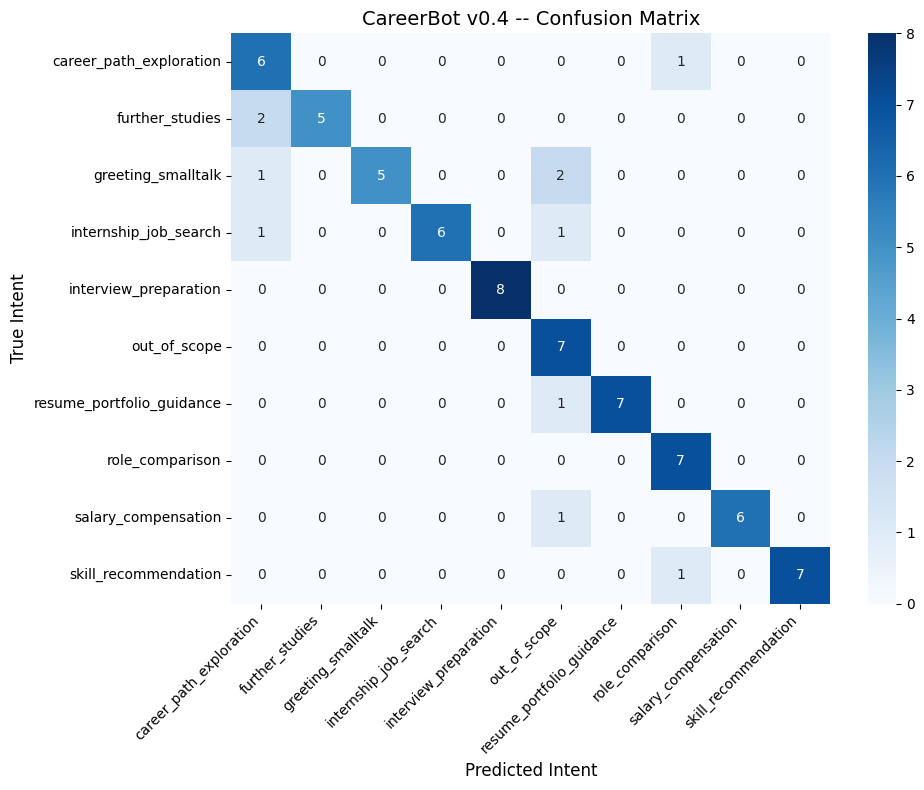

In [55]:
THRESHOLD = 0.35  # Cutoff below which queries are treated as out-of-scope

def classify_by_centroid(embeddings, centroids, threshold=THRESHOLD):
    """Classifies embeddings by finding highest cosine similarity against centroids."""
    intent_names = list(centroids.keys())
    centroid_matrix = np.stack([centroids[i] for i in intent_names])
    sims = embeddings @ centroid_matrix.T

    predictions = []
    for row_sims in sims:
        best_idx = row_sims.argmax()
        best_score = row_sims[best_idx]
        if best_score < threshold:
            predictions.append("out_of_scope")
        else:
            predictions.append(intent_names[best_idx])
    return predictions

# Run predictions on the test set
preds = classify_by_centroid(test_emb, centroids)
y_true = test_df["intent"].tolist()

# Compute evaluation metrics
acc = accuracy_score(y_true, preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)

print(f"Accuracy:        {acc:.3f}")
print(f"Macro Precision: {precision:.3f}")
print(f"Macro Recall:    {recall:.3f}")
print(f"Macro F1:        {f1:.3f}")
print()
print("Classification Report:")
print(classification_report(y_true, preds, zero_division=0))

# Generate and plot Confusion Matrix
labels = sorted(df["intent"].unique())
cm = confusion_matrix(y_true, preds, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Intent", fontsize=12)
plt.ylabel("True Intent", fontsize=12)
plt.title("CareerBot v0.4 -- Confusion Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Combine Dataset

In [ ]:
# ==========================================
# CELL 6: Strict CS Domain Guardrail & Helpers
# ==========================================

# Define core Computer Studies anchor phrases for semantic comparison
NON_CS_KEYWORDS = ["architecture", "nursing", "law", "medicine", "accounting", "civil engineering"]
CS_ANCHORS = [
    "computer science career path", "information technology jobs",
    "software engineering skills", "programming internship",
    "coding interview preparation", "data science career",
    "cybersecurity jobs", "computer engineering work"
]

OUT_OF_SCOPE_MESSAGE = (
    "It is out of scope. I am an AI career counselor specialized exclusively in "
    "Computer Studies (Computer Science, Information Technology, Information Systems, "
    "Computer Engineering, and related computing fields). I cannot answer questions "
    "about architecture or other non-computing degree programs."
)

def is_valid_cs_query(query):
    """Semantic and keyword guardrail to ensure only computing queries pass through."""
    normalized_query = query.lower()

    # Rule 1: Instant block if any non-CS keyword is explicitly mentioned
    for keyword in NON_CS_KEYWORDS:
        if keyword in normalized_query:
            return False

    # Rule 2: Semantic check using Sentence Transformer embeddings against CS anchors
    query_emb = embed_texts([query])
    anchor_embs = embed_texts(CS_ANCHORS)

    # Compute maximum similarity score against any CS anchor
    similarities = query_emb @ anchor_embs.T
    max_sim = float(similarities.max())

    # If the query is too far off from computing topics (threshold 0.38)
    if max_sim < 0.38:
        return False

    return True

print("Cell 6 loaded: Guardrails and helper functions are ready.")

Cell 6 loaded: Guardrails and helper functions are ready.


## 7. Train/Test Split

In [ ]:
# ==========================================
# CELL 7: Groq Integration & Whitelist Guardrail
# ==========================================
from groq import Groq

# Initialize Groq client
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
groq_client = Groq(api_key=GROQ_API_KEY)

# Whitelisted Computer Studies terms (Must contain at least one of these to be answered)
ALLOWED_CS_TERMS = [
    'cs', 'it', 'is', 'cpe', 'bscs', 'bsit', 'bsis', 'bscpe',
    'computer science', 'information technology', 'information systems',
    'computer engineering', 'software engineering', 'programmer', 'coding',
    'developer', 'data science', 'cybersecurity', 'tech', 'computing'
]

# Improved, more professional and welcoming refusal message
REFUSAL_MESSAGE = (
    "I'm sorry, but I can only assist with career questions related to Computer Studies "
    "(such as BSCS, BSIT, BSIS, and BSCpE programs). As a specialized computing career "
    "counselor, I am unable to provide guidance on other fields, degree programs, or general topics."
)

def chat_fn(message, history):
    normalized_message = message.lower()

    # 1. STRICT WHITELIST CHECK: Does the message contain any computer studies term?
    has_cs_term = any(term in normalized_message for term in ALLOWED_CS_TERMS)

    if not has_cs_term:
        return f"{REFUSAL_MESSAGE}\n\n*(Detected Intent: `out_of_scope` | Similarity: `0.000`)*"

    # 2. Normal intent detection for valid inputs that passed the whitelist
    # (Using the global model and centroids context from previous cells)
    query_emb = embed_texts([message])
    predictions = classify_by_centroid(query_emb, centroids)
    intent = predictions[0]

    # Let's get the max score against centroids for debugging visualization
    intent_names = list(centroids.keys())
    centroid_matrix = np.stack([centroids[i] for i in intent_names])
    sims = query_emb @ centroid_matrix.T
    score = float(sims.max())

    if intent == "out_of_scope" or score < THRESHOLD:
        return f"{REFUSAL_MESSAGE}\n\n*(Detected Intent: `{intent}` | Similarity: `{score:.3f}`)*"

    # 3. Groq generation for approved CS topics only
    system_prompt = f"""
    You are CareerBot, an expert AI career counselor exclusively for Computer Studies students (BSCS, BSIT, BSIS, BSCpE).
    The user's query has been classified under the intent: '{intent}'.
    Provide professional, concise guidance (under 3 paragraphs) strictly tailored to computing/tech fields.
    """

    try:
        completion = groq_client.chat.completions.create(
            model="openai/gpt-oss-20b",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": message}
            ],
            temperature=0.3,
            max_tokens=400
        )
        answer = completion.choices[0].message.content
    except Exception as e:
        answer = REFUSAL_MESSAGE

    return f"{answer}\n\n*(Detected Intent: `{intent}` | Similarity: `{score:.3f}`)*"

# Launch Gradio Chat Interface
demo = gr.ChatInterface(
    fn=chat_fn,
    title="CareerBot (Computer Studies Whitelist)",
    description="An AI career guidance chatbot locked exclusively to BSCS, BSIT, BSIS, and BSCpE.",
    examples=[
        "What career paths can I take as a BSCS grad?",
        "What skills do I need for BSIT data science?",
        "What job can I get if I'm an architecture student?", # Will be blocked!
        "What's the weather today?", # Will be blocked!
    ],
)

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ce2edb6f1e5b09f228.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Notes for the Group

- **Persistence is now handled automatically.** First run computes and saves centroids to `MyDrive/CareerBot/centroids.pkl`. Every run after that loads instantly instead of recomputing.
- **If you update your seed/augmented data**, delete `centroids.pkl` from Drive (or run `os.remove(CENTROIDS_PATH)`) so it recomputes with the new data next run.
- **Anyone opening this notebook needs their own Drive mounted** (it saves to whoever's Drive is connected), if teammates run it, each will get their own saved copy unless you explicitly share the Drive folder.
- **For the future web app**, this same `centroids.pkl` file is exactly what your backend (Flask/FastAPI) would load on startup, no need to recompute there either.